# **Proyecto Final – Aplicación de Machine Learning a un Caso Real**

**Objetivo**

Desarrollar un proyecto de ciencia de datos utilizando un conjunto de datos de libre elección. Deberás formular una pregunta de negocio o investigación y aplicar técnicas de análisis de datos y aprendizaje automático para responderla.

El proyecto puede enfocarse en cualquiera de las siguientes áreas:

    • Aprendizaje Supervisado
    • Aprendizaje No Supervisado
    • Procesamiento de Lenguaje Natural (NLP)
    • Deep Learning


# **Requisitos mínimos**
Definición del problema

Presentar:

    • Contexto del problema:
    Una tienda de e-commerce de ropa femenina recopila reseñas de sus clienta(calificación, texto,
    si recomiendan el producto, edad, categoría del producto). Entender qué hace que una clienta esté satisfecha
    o no es clave para reducir devoluciones y mejorar el catálogo.

    • Objetivo del proyecto:
    Analizar las reseñas para predecir si una clienta recomienda un producto, segmentar el comportamiento
    de las clientas, y extraer el sentimiento de sus comentarios de texto

    • Pregunta de negocio o investigación:
    ¿Qué factores (categoría de producto, edad de la clienta, calificación) predicen si una clienta recomienda
    el producto, y qué dicen los comentarios de texto sobre los motivos de satisfacción o insatisfacción?

    • Justificación de la elección del dataset:
    Es un dataset real, de una tienda real, de una sola tabla (fácil de manejar),
    y permite cubrir Supervisado (predecir recomendación),
    No Supervisado (segmentación de clientas)
    y NLP (sentimiento del texto) en una sola narrativa coherente.



# Obtención y comprensión de los datos


Podrás utilizar datasets provenientes de:

    • Kaggle
    • UCI Machine Learning Repository
    • Datos Abiertos Colombia
    • APIs públicas
    • Datos propios (anonimizados)

Debe incluir:

    • Descripción de las variables.
    • Dimensiones del dataset.
    • Tipos de datos.
    • Diccionario de datos (si está disponible).

# Análisis Exploratorio de Datos (EDA)


Realizar:

    • Estadísticas descriptivas.
    • Identificación de valores nulos.
    • Detección de valores atípicos.
    • Visualizaciones relevantes.
    • Hallazgos principales.

In [37]:
# Manipulación de datos
import pandas as pd
import numpy as np

#Visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

#1. Carga de Datasets (Para pruebas)
from sklearn.datasets import load_iris
# 2. Preparación y Preprocesamiento de datos
from sklearn.preprocessing import StandardScaler

# 3. Reducción de Dimensionalidad (Para visualización o modelado)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Evaluación y Métricas
from sklearn import metrics

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


In [2]:
from google.colab import files
uloaded =files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


In [3]:
df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
#informacion general de dataset
print('total de filas y columnas:', df.shape)

total de filas y columnas: (23486, 11)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
df. describe(include="all")

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
count,23486.000000,23486.000000,23486.000000,19676,22641,23486.000000,23486.000000,23486.000000,23472,23472,23472
unique,NaN,NaN,NaN,13993,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliment...,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,NaN,136,3,NaN,NaN,NaN,13850,10468,6319
mean,11742.500000,918.118709,43.198544,NaN,NaN,4.196032,0.822362,2.535936,NaN,NaN,NaN
std,6779.968547,203.298980,12.279544,NaN,NaN,1.110031,0.382216,5.702202,NaN,NaN,NaN
min,0.000000,0.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,5871.250000,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,11742.500000,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,17613.750000,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


In [7]:
#Tipos de datos
df.dtypes

,0
Unnamed: 0,int64
Clothing ID,int64
Age,int64
Title,object
Review Text,object
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,object
Department Name,object


In [8]:
#Revisar datos nulos
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [9]:
#Duplicados
df.duplicated().sum()

np.int64(0)

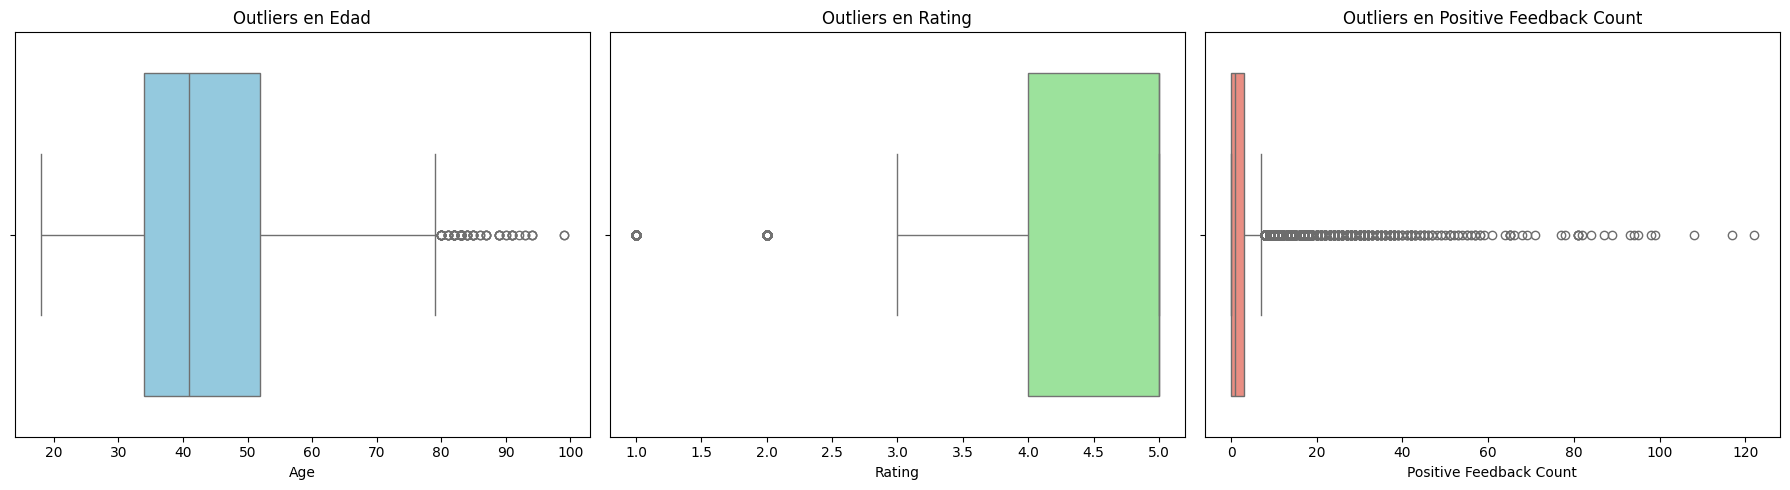

In [10]:
# Configuramos una ventana con 3 subgráficos (uno para cada columna numérica)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gráfico para la Edad (Age)
sns.boxplot(ax=axes[0], x=df['Age'], color='skyblue')
axes[0].set_title('Outliers en Edad')

# 2. Gráfico para Calificación (Rating)
sns.boxplot(ax=axes[1], x=df['Rating'], color='lightgreen')
axes[1].set_title('Outliers en Rating')

# 3. Gráfico para Feedback Positivo (Positive Feedback Count)
sns.boxplot(ax=axes[2], x=df['Positive Feedback Count'], color='salmon')
axes[2].set_title('Outliers en Positive Feedback Count')

plt.tight_layout()
plt.show()

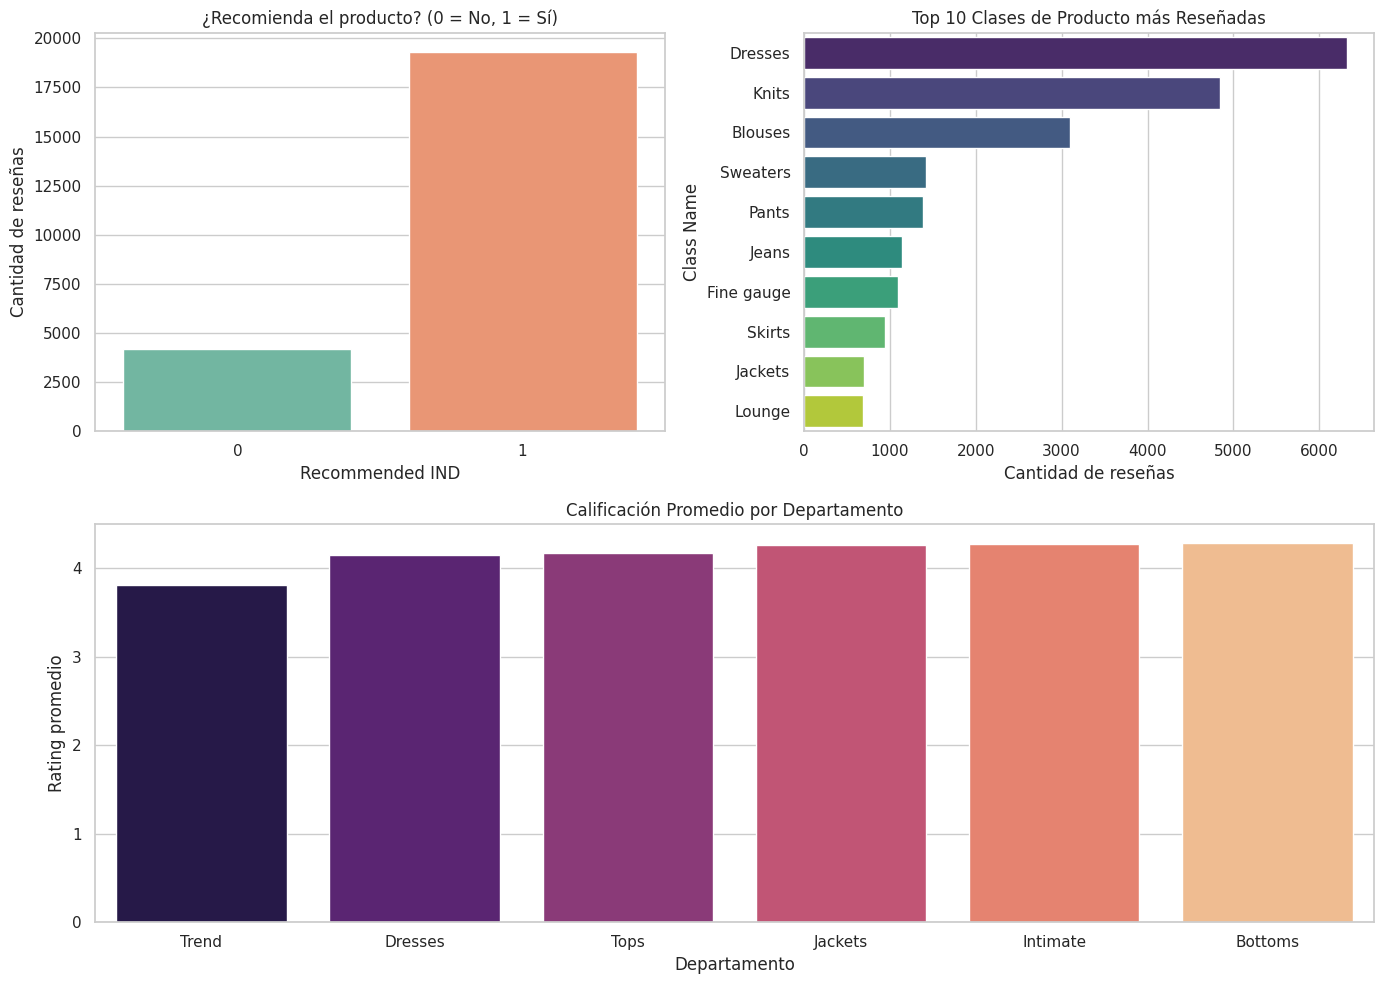

In [11]:
#Visualizacion: distribucion de Rating

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Visualización 1: ¿El cliente recomienda el producto?
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Recommended IND', hue='Recommended IND', palette='Set2', legend=False)
plt.title('¿Recomienda el producto? (0 = No, 1 = Sí)')
plt.xlabel('Recommended IND')
plt.ylabel('Cantidad de reseñas')

# Visualización 2: Top 10 clases de producto más reseñadas
plt.subplot(2, 2, 2)
top_clases = df['Class Name'].value_counts().head(10)
sns.barplot(x=top_clases.values, y=top_clases.index, hue=top_clases.index, palette='viridis', legend=False)
plt.title('Top 10 Clases de Producto más Reseñadas')
plt.xlabel('Cantidad de reseñas')

# Visualización 3: Calificación promedio por departamento (fila completa)
plt.subplot(2, 2, (3, 4))
rating_depto = df.groupby('Department Name')['Rating'].mean().sort_values()
sns.barplot(x=rating_depto.index, y=rating_depto.values, hue=rating_depto.index, palette='magma', legend=False)
plt.title('Calificación Promedio por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Rating promedio')

plt.tight_layout()
plt.show()

In [12]:
# Estadísticos para las variables numéricas (Age, Rating, Positive Feedback Count)
print("=== Variables Numéricas ===")
display(df.describe())

# Estadísticos para las variables categóricas (Title, Review Text, Division/Department/Class Name)
print("\n=== Variables Categóricas ===")
display(df.describe(include=['object']))

=== Variables Numéricas ===


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000



=== Variables Categóricas ===


,Title,Review Text,Division Name,Department Name,Class Name
count,19676,22641,23472,23472,23472
unique,13993,22634,3,6,20
top,Love it!,Perfect fit and i've gotten so many compliment...,General,Tops,Dresses
freq,136,3,13850,10468,6319


#Diccionario

| Columna | Descripción |
|---|---|
| Clothing ID | Identificador único del producto |
| Age | Edad de la clienta |
| Title | Título corto de la reseña |
| Review Text | Comentario completo de la reseña (texto libre) |
| Rating | Calificación otorgada, del 1 al 5 |
| Recommended IND | 1 si la clienta recomienda el producto, 0 si no |
| Positive Feedback Count | Cantidad de personas que marcaron la reseña como útil |
| Division Name | Categoría general del producto |
| Department Name | Departamento del producto (Tops, Dresses, Bottoms, etc.) |
| Class Name | Clase específica del producto (Blouses, Jeans, Sweaters, etc.) |




# Preparación de datos


Según corresponda:

    • Limpieza de datos.
    • Tratamiento de valores faltantes.
    • Codificación de variables categóricas.
    • Escalamiento o normalización.
    • Ingeniería de características.
    • División entrenamiento/prueba.


In [13]:
#Limpieza de datos
# Eliminar columna que no aporta (índice duplicado)
df = df.drop(columns=['Unnamed: 0'])

# Eliminar las 14 filas sin categoría de producto (son muy pocas, no afecta el análisis)
df = df.dropna(subset=['Division Name', 'Department Name', 'Class Name'])

print('Filas y columnas después de limpiar:', df.shape)

Filas y columnas después de limpiar: (23472, 10)


In [14]:
#Tratamiento de valores faltantes
df['Title'] = df['Title'].fillna('')
df['Review Text'] = df['Review Text'].fillna('')

print(df.isnull().sum())

Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


In [15]:
#Codificacion de variables categoricas
df_encoded = pd.get_dummies(df, columns=['Division Name', 'Department Name', 'Class Name'], drop_first=True)

print('Columnas antes:', df.shape[1])
print('Columnas despues:', df_encoded.shape[1])
df_encoded.head()

Columnas antes: 10
Columnas despues: 33


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name_General Petite,Division Name_Initmates,Department Name_Dresses,...,Class Name_Legwear,Class Name_Lounge,Class Name_Outerwear,Class Name_Pants,Class Name_Shorts,Class Name_Skirts,Class Name_Sleep,Class Name_Sweaters,Class Name_Swim,Class Name_Trend
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
#Escalamiento de variables numericas
scaler = StandardScaler()
columnas_numericas = ['Age', 'Positive Feedback Count']

df_encoded[columnas_numericas] = scaler.fit_transform(df_encoded[columnas_numericas])

df_encoded[columnas_numericas].describe()

,Age,Positive Feedback Count
count,2.347200e+04,2.347200e+04
mean,7.356079e-17,3.995895e-17
std,1.000021e+00,1.000021e+00
min,-2.052066e+00,-4.448429e-01
25%,-7.492035e-01,-4.448429e-01
50%,-1.792012e-01,-2.695112e-01
75%,7.165168e-01,8.115216e-02
max,4.543675e+00,2.094562e+01


In [17]:
#Ingenieria de caracteristicas

# 1. Longitud de la reseña (cantidad de palabras) - útil como predictor y para NLP
df_encoded['review_length'] = df['Review Text'].apply(lambda x: len(x.split()))

# 2. Grupo de edad - agrupa edades individuales en rangos, más fácil de interpretar
df_encoded['age_group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])

df_encoded[['review_length', 'age_group']].head()

,review_length,age_group
0,8,31-45
1,62,31-45
2,98,46-60
3,22,46-60
4,36,46-60


# Modelado


Elige una de las siguientes rutas:

Ruta A – Aprendizaje Supervisado

Debe incluir:

    • Al menos 2 modelos diferentes.
    • Comparación de resultados.
    • Métricas adecuadas.

Ruta B – Aprendizaje No Supervisado


Debe incluir:

    • Al menos 2 técnicas.
    • Interpretación de los grupos encontrados.
Ruta C – NLP

Debe incluir:

    • Preprocesamiento de texto.
    • Vectorización.
    • Entrenamiento y evaluación.


# Aprendizaje Supervisado

In [18]:
#Division entrenamiento/prueba
X = df_encoded.drop(columns=['Recommended IND', 'Title', 'Review Text', 'age_group'])
y = df_encoded['Recommended IND']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
#Escalar review_length
scaler2 = StandardScaler()
X_train['review_length'] = scaler2.fit_transform(X_train[['review_length']])
X_test['review_length'] = scaler2.transform(X_test[['review_length']])

In [20]:
#Modelo 1: Regresion Logistica

modelo_lr = LogisticRegression(max_iter=3000, random_state=42)
modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

print("=== Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1-score:", f1_score(y_test, pred_lr))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, pred_lr))

=== Regresión Logística ===
Accuracy: 0.9358892438764643
Precision: 0.9760043138312213
Recall: 0.9446764091858038
F1-score: 0.9600848693807187

Matriz de confusión:
 [[ 774   89]
 [ 212 3620]]


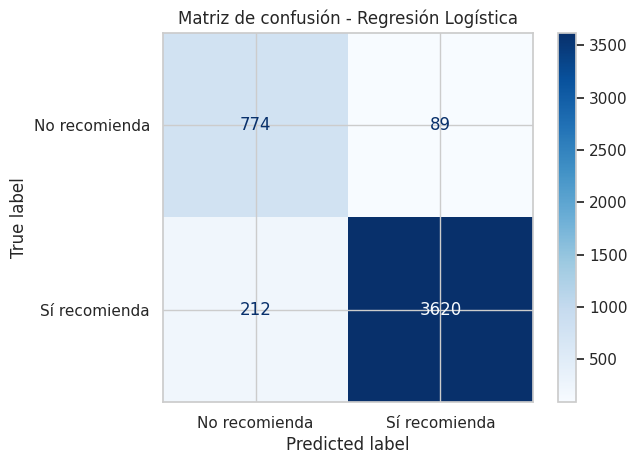

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       863
           1       0.98      0.94      0.96      3832

    accuracy                           0.94      4695
   macro avg       0.88      0.92      0.90      4695
weighted avg       0.94      0.94      0.94      4695



In [23]:
matriz_confusion = confusion_matrix(y_test, pred_lr)

mapa_calor = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['No recomienda', 'Sí recomienda'])
mapa_calor.plot(cmap='Blues')
plt.title('Matriz de confusión - Regresión Logística')
plt.show()

print(classification_report(y_test, pred_lr))

In [24]:
#Modelo 2: Random Forest

modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1-score:", f1_score(y_test, pred_rf))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, pred_rf))

=== Random Forest ===
Accuracy: 0.9324813631522897
Precision: 0.9650701243715268
Recall: 0.951722338204593
F1-score: 0.9583497569307581

Matriz de confusión:
 [[ 731  132]
 [ 185 3647]]


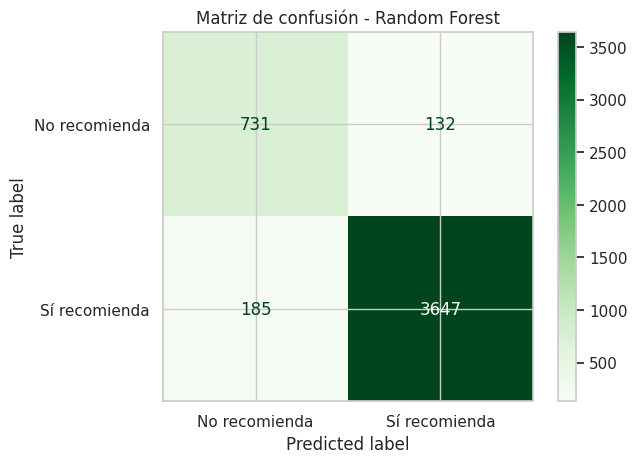

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       863
           1       0.97      0.95      0.96      3832

    accuracy                           0.93      4695
   macro avg       0.88      0.90      0.89      4695
weighted avg       0.93      0.93      0.93      4695



In [25]:
matriz_confusion_rf = confusion_matrix(y_test, pred_rf)

mapa_calor_rf = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_rf, display_labels=['No recomienda', 'Sí recomienda'])
mapa_calor_rf.plot(cmap='Greens')
plt.title('Matriz de confusión - Random Forest')
plt.show()

print(classification_report(y_test, pred_rf))

In [26]:
#Comparacion de resultados
comparacion = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, pred_lr), accuracy_score(y_test, pred_rf)],
    "Precision": [precision_score(y_test, pred_lr), precision_score(y_test, pred_rf)],
    "Recall": [recall_score(y_test, pred_lr), recall_score(y_test, pred_rf)],
    "F1-score": [f1_score(y_test, pred_lr), f1_score(y_test, pred_rf)],
})

comparacion

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.935889,0.976004,0.944676,0.960085
1,Random Forest,0.932481,0.965070,0.951722,0.958350


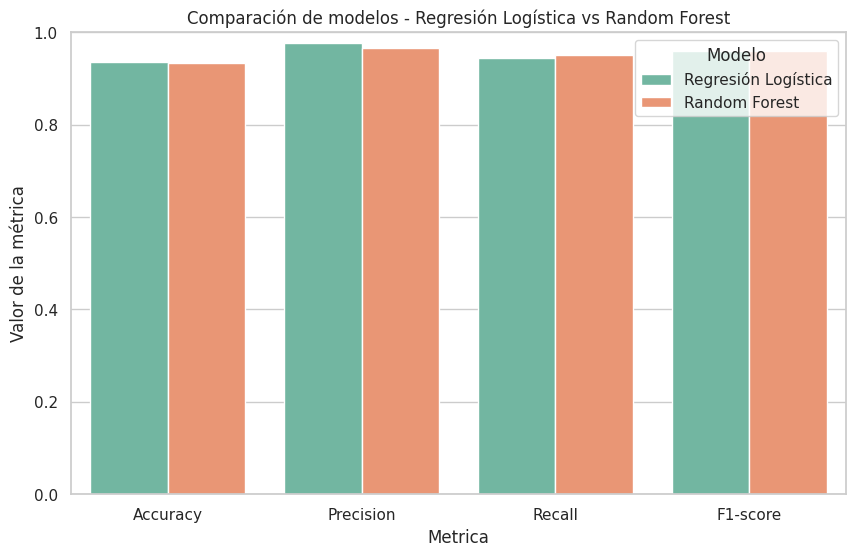

In [27]:
#Grafica comparativa de modelos
comparacion_larga = comparacion.melt(id_vars="Modelo", var_name="Metrica", value_name="Valor")

plt.figure(figsize=(10,6))
sns.barplot(data=comparacion_larga, x="Metrica", y="Valor", hue="Modelo", palette="Set2")
plt.title("Comparación de modelos - Regresión Logística vs Random Forest")
plt.ylim(0, 1)
plt.ylabel("Valor de la métrica")
plt.show()

# Aprendizaje No Supervisado

In [28]:
#Preparar datos para clustering
columnas_cluster = ['Age', 'Rating', 'Positive Feedback Count', 'review_length']
X_cluster = df_encoded[columnas_cluster]

X_cluster.head()

,Age,Rating,Positive Feedback Count,review_length
0,-0.830632,4,-0.444843,8
1,-0.749204,5,0.256484,62
2,1.367948,3,-0.444843,98
3,0.553659,5,-0.444843,22
4,0.309372,5,0.607147,36


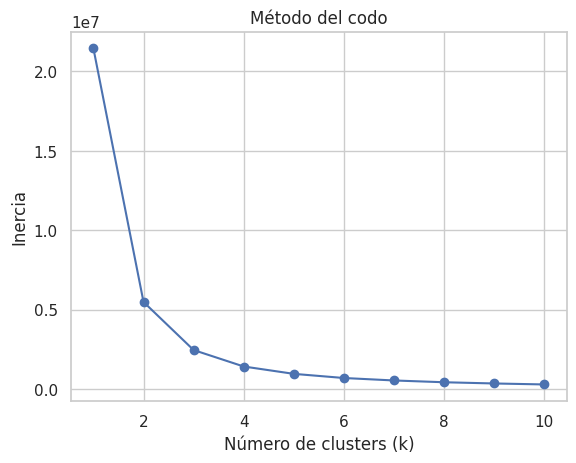

In [29]:
#Metodo del codo para elegir el numero de clusters
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inercia.append(kmeans.inertia_)

plt.plot(rango_k, inercia, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.show()

In [30]:
#Modelo K-Means con k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_encoded['cluster_kmeans'] = kmeans_final.fit_predict(X_cluster)

df_encoded['cluster_kmeans'].value_counts()

,count
cluster_kmeans,
0,7213
1,6218
2,5872
3,4169


In [31]:
#Interpretacion de los clusters
df_encoded.groupby('cluster_kmeans')[columnas_cluster].mean()

,Age,Rating,Positive Feedback Count,review_length
cluster_kmeans,,,,
0,0.045228,4.134895,0.266620,94.431721
1,-0.019761,4.184947,-0.135658,39.013027
2,-0.032679,4.145266,0.010118,64.539339
3,-0.002749,4.387143,-0.273212,14.339650


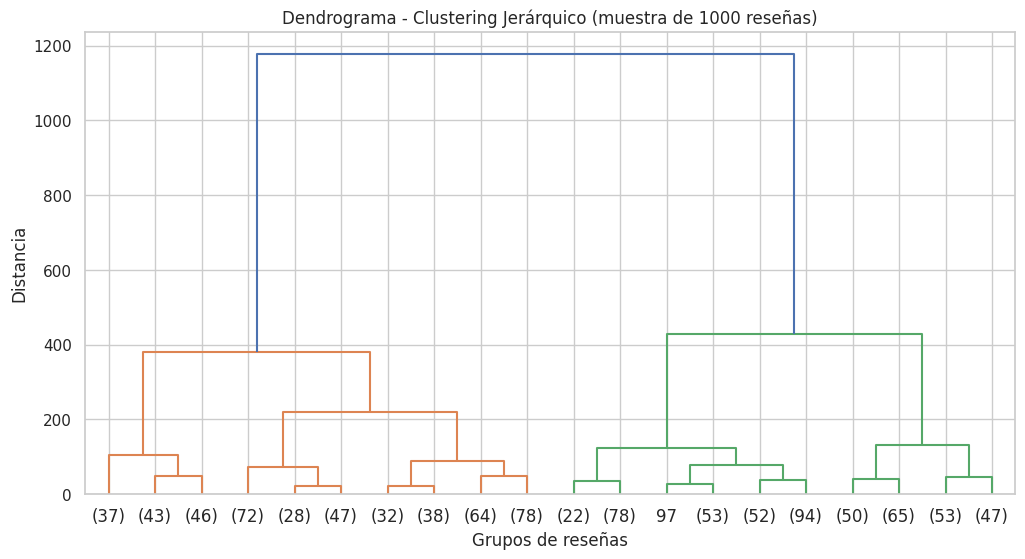

In [35]:
#Clustering Jerarquico - Dendrograma

# Tomamos una muestra de 1000 reseñas para que sea manejable
muestra = X_cluster.sample(1000, random_state=42)

plt.figure(figsize=(12, 6))
enlaces = linkage(muestra, method='ward')
dendrogram(enlaces, truncate_mode='lastp', p=20)
plt.title('Dendrograma - Clustering Jerárquico (muestra de 1000 reseñas)')
plt.xlabel('Grupos de reseñas')
plt.ylabel('Distancia')
plt.show()

In [38]:
#Clustering Jerarquico - Aplicar con 4 grupos
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
muestra_con_cluster = muestra.copy()
muestra_con_cluster['cluster_jerarquico'] = agglo.fit_predict(muestra)

muestra_con_cluster.groupby('cluster_jerarquico')[columnas_cluster].mean()

,Age,Rating,Positive Feedback Count,review_length
cluster_jerarquico,,,,
0,0.062364,4.130919,-0.114203,38.757660
1,0.014334,4.167442,-0.039541,68.400000
2,-0.027743,4.040000,0.250639,95.476667
3,0.126480,4.396825,-0.334913,10.865079


In [39]:
#Preprocesamiento de texto
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Solo reseñas con texto real
df_nlp = df_encoded[df['Review Text'].str.len() > 0].copy()
df_nlp['Review Text'] = df['Review Text']  # texto original, no el escalado

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', '', texto)  # quitar números y signos de puntuación
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return ' '.join(palabras)

df_nlp['texto_limpio'] = df_nlp['Review Text'].apply(limpiar_texto)

df_nlp[['Review Text', 'texto_limpio']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Review Text,texto_limpio
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...


In [40]:
#Vectorizacion con TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(max_features=1000)  # las 1000 palabras mas relevantes
X_texto = vectorizador.fit_transform(df_nlp['texto_limpio'])

print("Forma de la matriz:", X_texto.shape)

Forma de la matriz: (22628, 1000)


In [41]:
#Entrenamiento del modelo NLP
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

y_texto = df_nlp['Recommended IND']

X_train_texto, X_test_texto, y_train_texto, y_test_texto = train_test_split(
    X_texto, y_texto, test_size=0.2, random_state=42
)

modelo_nlp = LogisticRegression(max_iter=1000, random_state=42)
modelo_nlp.fit(X_train_texto, y_train_texto)

pred_nlp = modelo_nlp.predict(X_test_texto)

print("Accuracy:", accuracy_score(y_test_texto, pred_nlp))
print("\n", classification_report(y_test_texto, pred_nlp))

Accuracy: 0.8820150243040212

               precision    recall  f1-score   support

           0       0.77      0.52      0.62       845
           1       0.90      0.97      0.93      3681

    accuracy                           0.88      4526
   macro avg       0.84      0.74      0.78      4526
weighted avg       0.87      0.88      0.87      4526



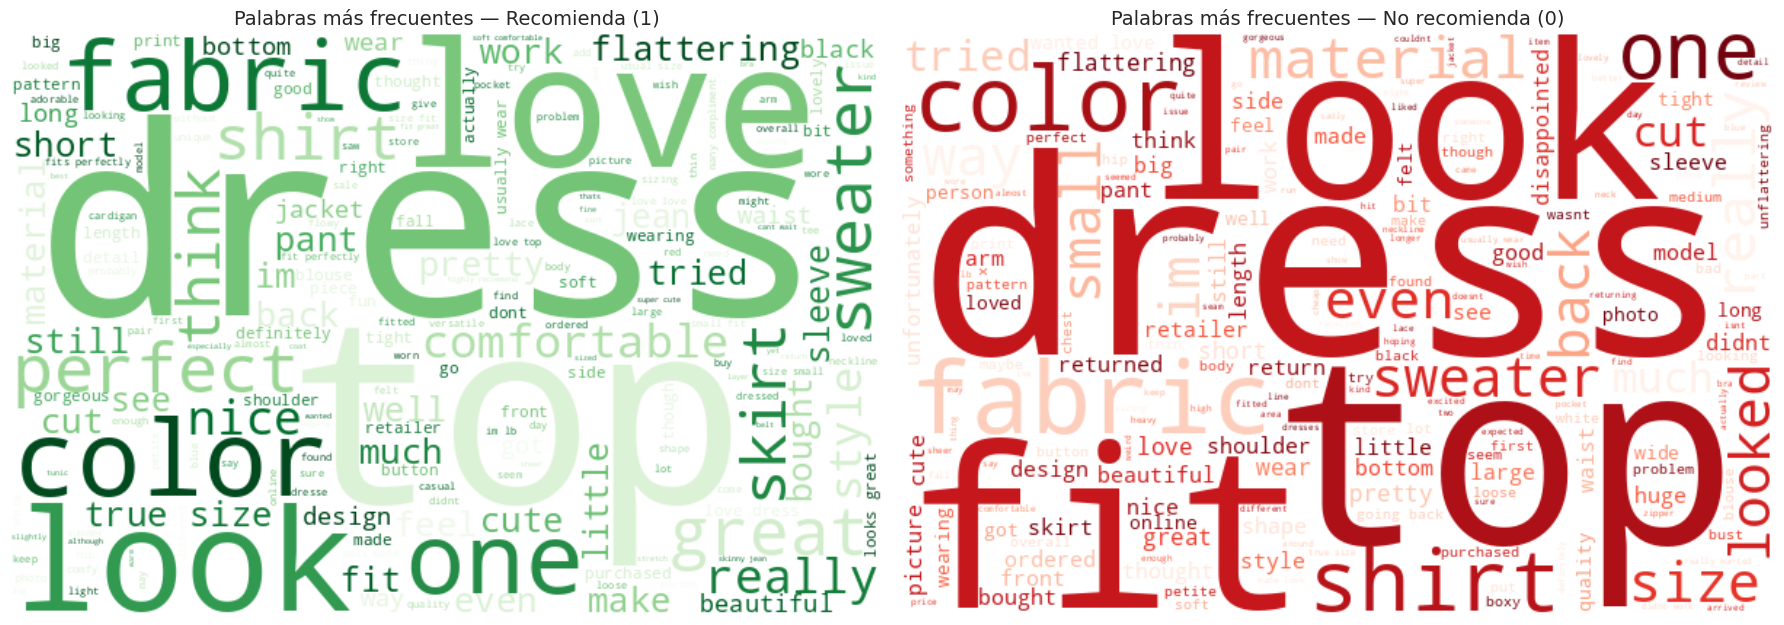

In [42]:
#Palabras mas frecuentes: reseñas positivas vs negativas
!pip install wordcloud -q
from wordcloud import WordCloud

texto_positivo = ' '.join(df_nlp[df_nlp['Recommended IND'] == 1]['texto_limpio'])
texto_negativo = ' '.join(df_nlp[df_nlp['Recommended IND'] == 0]['texto_limpio'])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(texto_positivo)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Palabras más frecuentes — Recomienda (1)', fontsize=14)
axes[0].axis('off')

wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(texto_negativo)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Palabras más frecuentes — No recomienda (0)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [45]:
#Exportar todo para el dashboard
import pandas as pd
comparacion.to_csv('dashboard_comparacion_modelos.csv', index=False, encoding='utf-8-sig')

# Dataset principal con clusters incluidos
df_dashboard = df.copy()
df_dashboard['cluster_kmeans'] = df_encoded['cluster_kmeans']
df_dashboard.to_csv('dashboard_datos.csv', index=False)

# Comparacion de modelos supervisados
comparacion.to_csv('dashboard_comparacion_modelos.csv', index=False)

# Texto limpio para NLP (nube de palabras)
df_nlp[['texto_limpio', 'Recommended IND']].to_csv('dashboard_texto_nlp.csv', index=False)

from google.colab import files
files.download('dashboard_datos.csv')
files.download('dashboard_comparacion_modelos.csv')
files.download('dashboard_texto_nlp.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>